In [1]:
import numpy as np

from tqdm import tqdm
from matplotlib import pyplot as plt

import pickle

import torch
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
from models.ALISTA import ALISTA
from models.LISTA_CPSS import LISTA_CPSS

from models.ALDCISTA import ALDC_ISTA
from models.L_DC_ISTA_CPSS import L_DC_ISTA_CPSS

from models.LePOM import LePOM_CP
from models.ALePOM import ALePOM

from utils.train import layerwise_train
from utils.synthetic_data import SyntheticSignals, SyntheticSignalsOnline

# Reconstruction in noisy scenarios (noiseless training)

In [3]:
n_ = 500
m_ = 250
p_ = 0.1

torch.random.manual_seed(42)
A_ = torch.normal(0, torch.sqrt(torch.tensor(1/m_)), size = (m_, n_))
A_ /= torch.linalg.norm(A_, dim = 0)

'''
train_set = SyntheticSignals(
        A = A_,
        n = n_,        
        m = m_,
        p = p_,
        SNR = None,
        size = 50000,
        batch_size = 64
        ).set_loader()

val_set = SyntheticSignals(
        A = A_,
        n = n_,        
        m = m_,
        p = p_,
        SNR = None,
        size = 50000,
        batch_size = 1000
        ).set_loader()
'''

generator = SyntheticSignalsOnline(
        A = A_,
        n = n_,        
        m = m_,
        p = p_,
        SNR = None
        )

In [ ]:
model_1 = ALISTA(torch.clone(A_), 0.4, T = 16, SS = True)
layerwise_train(model_1, 'C', 'ALISTA', generator, lr = 1e-3, ft_lr = 1e-3, verbose=True)

Linear layer initialized minimizing coherence!
===== Training Layer 0/16 =====
Layer 0, Step 1, Train NMSE (dB): -1.402367, Validation NMSE (dB): -1.440627
Layer 0, Step 101, Train NMSE (dB): -3.912103, Validation NMSE (dB): -4.005283
Layer 0, Step 201, Train NMSE (dB): -5.163917, Validation NMSE (dB): -5.253476
Layer 0, Step 301, Train NMSE (dB): -5.545130, Validation NMSE (dB): -5.663863
Layer 0, Step 401, Train NMSE (dB): -5.733876, Validation NMSE (dB): -5.804337
Layer 0, Step 501, Train NMSE (dB): -5.944189, Validation NMSE (dB): -5.884414
Layer 0, Step 601, Train NMSE (dB): -5.854781, Validation NMSE (dB): -5.948387
Layer 0, Step 701, Train NMSE (dB): -6.057150, Validation NMSE (dB): -6.003481
Layer 0, Step 801, Train NMSE (dB): -6.078828, Validation NMSE (dB): -6.049801
Layer 0, Step 901, Train NMSE (dB): -6.131834, Validation NMSE (dB): -6.087411
Layer 0, Step 1001, Train NMSE (dB): -6.183326, Validation NMSE (dB): -6.117699
Layer 0, Step 1101, Train NMSE (dB): -6.111273, Valid

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


Layer 1, Step 1601, Train NMSE (dB): -8.749688, Validation NMSE (dB): -8.632614
Layer 1, Step 1701, Train NMSE (dB): -8.605590, Validation NMSE (dB): -8.633155
Layer 1, Step 1801, Train NMSE (dB): -8.687934, Validation NMSE (dB): -8.633179
Layer 1, Step 1901, Train NMSE (dB): -8.500436, Validation NMSE (dB): -8.633202
Layer 1, Step 2001, Train NMSE (dB): -8.283955, Validation NMSE (dB): -8.632896
Layer 1, Step 2101, Train NMSE (dB): -8.646882, Validation NMSE (dB): -8.633107
Layer 1, Step 2201, Train NMSE (dB): -8.551486, Validation NMSE (dB): -8.633085
Layer 1, Step 2301, Train NMSE (dB): -8.648754, Validation NMSE (dB): -8.632902
Early stopping triggered due to small improvement: 0.000991
===== Finished Training Layer 1/16 =====

===== Fine-Tuning the Entire Network =====
Layer 1, Step 1, Train NMSE (dB): -8.959108, Validation NMSE (dB): -8.644426
Layer 1, Step 101, Train NMSE (dB): -9.357714, Validation NMSE (dB): -9.397483
Layer 1, Step 201, Train NMSE (dB): -9.561519, Validation N

In [ ]:
model_2 = ALDC_ISTA(torch.clone(A_), 'PNEG', 0.4, T = 16, W = torch.clone(model_1.W).to('cuda:0'), SS = True)
layerwise_train(model_2, 'DC', 'AL-DC-ISTA', generator, 'PNEG', lr = 1e-3, ft_lr = 1e-3, verbose=True)

===== Training Layer 0/16 =====
Layer 0, Step 1, Train NMSE (dB): -0.126509, Validation NMSE (dB): -0.136535
Layer 0, Step 101, Train NMSE (dB): -1.155833, Validation NMSE (dB): -1.147886
Layer 0, Step 201, Train NMSE (dB): -2.092413, Validation NMSE (dB): -2.040798
Layer 0, Step 301, Train NMSE (dB): -2.727818, Validation NMSE (dB): -2.761620
Layer 0, Step 401, Train NMSE (dB): -3.240301, Validation NMSE (dB): -3.272761
Layer 0, Step 501, Train NMSE (dB): -3.608792, Validation NMSE (dB): -3.602183
Layer 0, Step 601, Train NMSE (dB): -3.780147, Validation NMSE (dB): -3.809305
Layer 0, Step 701, Train NMSE (dB): -4.013738, Validation NMSE (dB): -3.950637
Layer 0, Step 801, Train NMSE (dB): -4.144631, Validation NMSE (dB): -4.064035
Layer 0, Step 901, Train NMSE (dB): -4.200736, Validation NMSE (dB): -4.169881
Layer 0, Step 1001, Train NMSE (dB): -4.343830, Validation NMSE (dB): -4.276841
Layer 0, Step 1101, Train NMSE (dB): -4.479443, Validation NMSE (dB): -4.385982
Layer 0, Step 1201, 

Epoch,▃▃▅▂▂▅▁▃▂▃▅█▂▂▆▃█▃▃▄▂▆▁▅▄▁▂▂▃▃▂▂▃▂▂▂▁▁▁▂
Train NMSE (dB),████▇▇▇▇▇▇▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▄▃▄▃▃▃▃▂▂▂▂▁▂▁▁
Validation NMSE (dB),███▇▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▃▃▃▃▂▁▁▁▁
Epoch,2220
Train NMSE (dB),-59.66757
Validation NMSE (dB),-59.48803


({'Layer_1': [-0.12650943033642395,
   -0.13558895126503603,
   -0.15314382714306587,
   -0.15263325735937286,
   -0.15850863505584403,
   -0.17902716960198226,
   -0.18462794832110901,
   -0.20132132661641317,
   -0.21235258603863838,
   -0.20972779279119264,
   -0.23536748201687555,
   -0.24765754288020547,
   -0.24081119330371717,
   -0.26187532707553407,
   -0.2551441246370601,
   -0.29236246329349924,
   -0.28374350056889364,
   -0.2927278153979613,
   -0.31902196409261174,
   -0.3193427101976403,
   -0.34207830589509935,
   -0.3422946801745668,
   -0.35004643692693205,
   -0.3574378914473722,
   -0.38497853119950154,
   -0.3933718301221637,
   -0.3972907958211426,
   -0.41399696268978614,
   -0.4231232664624643,
   -0.4410162910974018,
   -0.4265033480204469,
   -0.4450229548093537,
   -0.45539136787078227,
   -0.4695392725788928,
   -0.4769116713220601,
   -0.4880208904717225,
   -0.5106749736364795,
   -0.5184924697680479,
   -0.5315525944138779,
   -0.5380870126417809,
   -0.5

In [ ]:
model_3 = LISTA_CPSS(torch.clone(A_), 0.4, T = 16, SS = True)
layerwise_train(model_3, 'C', 'LISTA-CPSS', generator, lr = 1e-3, ft_lr = 1e-3, verbose=True)

In [ ]:
model_4 = L_DC_ISTA_CPSS(torch.clone(A_), 'PNEG', 0.4, T = 16, SS = True)
layerwise_train(model_4, 'DC', 'L-DC-ISTA-CPSS', generator, 'PNEG', lr = 1e-3, ft_lr =  1e-3, verbose=True)

In [ ]:
model_5 = ALePOM(torch.clone(A_), 0.4, T = 16, W = torch.clone(model_1.W).to('cuda:0'))
layerwise_train(model_5, 'POM', 'ALePOM', generator, lr = 1e-3, ft_lr =  1e-3, verbose=True)

===== Training Layer 0/16 =====
Layer 0, Step 1, Train NMSE (dB): 0.010813, Validation NMSE (dB): 0.011286
Layer 0, Step 101, Train NMSE (dB): -0.499742, Validation NMSE (dB): -0.511824
Layer 0, Step 201, Train NMSE (dB): -1.588276, Validation NMSE (dB): -1.590816
Layer 0, Step 301, Train NMSE (dB): -3.357017, Validation NMSE (dB): -3.217086
Layer 0, Step 401, Train NMSE (dB): -4.570595, Validation NMSE (dB): -4.638566
Layer 0, Step 501, Train NMSE (dB): -5.618413, Validation NMSE (dB): -5.484559
Layer 0, Step 601, Train NMSE (dB): -6.016501, Validation NMSE (dB): -5.896885
Layer 0, Step 701, Train NMSE (dB): -5.910503, Validation NMSE (dB): -6.075599
Layer 0, Step 801, Train NMSE (dB): -6.410138, Validation NMSE (dB): -6.158325
Layer 0, Step 901, Train NMSE (dB): -6.717456, Validation NMSE (dB): -6.200427
Layer 0, Step 1001, Train NMSE (dB): -6.245715, Validation NMSE (dB): -6.231380
Layer 0, Step 1101, Train NMSE (dB): -6.298839, Validation NMSE (dB): -6.256088
Layer 0, Step 1201, Tr

Epoch,▂▄▄▇▁▂▅▅▃▄▄▂▁▂▇▃▄▁▅▄▃██▄▂▅█▅▂▃▃▃▄▃▅▄▅▂▃▂
Train NMSE (dB),█████▇▇▇▇▇▇▇▇▇▆▅▅▅▄▃▃▃▃▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁
Validation NMSE (dB),███▇▇▇▇▇▇▇▆▆▆▆▆▅▅▄▄▄▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Epoch,2010
Train NMSE (dB),-59.91404
Validation NMSE (dB),-59.93258


({'Layer_1': [0.010813313052159396,
   0.002967215505762619,
   0.011762948686214747,
   0.0005073498686628421,
   -0.007503793231330932,
   -0.005557630813676221,
   -0.014268696499171328,
   -0.008751349993458373,
   -0.018454837562316306,
   -0.02742027657596539,
   -0.021367070207838665,
   -0.03603490911937799,
   -0.042621254160715785,
   -0.044416033248702864,
   -0.05040054792404253,
   -0.05087279512747157,
   -0.060254595086758525,
   -0.06306365199996199,
   -0.06986900969747163,
   -0.061902579356027485,
   -0.08298540728188052,
   -0.07923271564350262,
   -0.08719815034763656,
   -0.08951861343787687,
   -0.08732885309175917,
   -0.09665713483265259,
   -0.1006857501510762,
   -0.11324125477243761,
   -0.11813499422374682,
   -0.12256271929005466,
   -0.12168239842897913,
   -0.12766969510438914,
   -0.1252329779869615,
   -0.12899381980515173,
   -0.12997480794316185,
   -0.1420069428659272,
   -0.14173379603318356,
   -0.14455254541069606,
   -0.1625463366092909,
   -0.1

In [ ]:
model_6 = LePOM_CP(torch.clone(A_), 0.4, T = 16)
layerwise_train(model_6, 'POM', 'LePOM', generator, lr = 1e-3, ft_lr =  1e-3, verbose=True)

In [10]:
torch.save(A_, 'synthetic_sensing.pth')

In [ ]:
torch.save(model_1.state_dict(), "model_1_NOISY_weights.pth")
torch.save(model_2.state_dict(), "model_2_NOISY_weights.pth")
torch.save(model_3.state_dict(), "model_3_NOISY_weights.pth")
torch.save(model_4.state_dict(), "model_4_NOISY_weights.pth")
torch.save(model_5.state_dict(), "model_5_NOISY_weights.pth")
torch.save(model_6.state_dict(), "model_6_NOISY_weights.pth")

In [4]:
model_1 = ALISTA(torch.clone(A_), 0.1, T = 16, SS = False)
model_2 = ALDC_ISTA(torch.clone(A_), 'PNEG', 0.1, T = 16, W = torch.clone(model_1.W).to('cuda:0'), SS = False)
model_3 = LISTA_CPSS(torch.clone(A_), 0.1, T = 16, SS = False)
model_4 = L_DC_ISTA_CPSS(torch.clone(A_), 'PNEG', 0.1, T = 16, SS = False)
model_2 = ALDC_ISTA(torch.clone(A_), 'EXP', 0.4, T = 16, W = torch.clone(model_1.W).to('cuda:0'), SS = False)
model_5 = ALePOM(torch.clone(A_), 0.1, T = 16, W = torch.clone(model_1.W).to('cuda:0'))
model_6 = LePOM_CP(torch.clone(A_), 0.1, T = 16)

Linear layer initialized minimizing coherence!


In [ ]:
model_1.load_state_dict(torch.load('model_1_NOISY_weights.pth'))
model_2.load_state_dict(torch.load('model_2_NOISY_weights.pth'))
model_3.load_state_dict(torch.load('model_3_NOISY_weights.pth'))
model_4.load_state_dict(torch.load('model_4_NOISY_weights.pth'))
model_5.load_state_dict(torch.load('model_5_NOISY_weights.pth'))
model_6.load_state_dict(torch.load('model_6_NOISY_weights.pth'))

In [31]:
SNRs = [1] + list(range(5,81,5))
n_ = 500
m_ = 250
p_ = 0.1

noisy_scenarios = {SNR: {
    'ALISTA':0,
    'LISTA-CPSS':0,
    'AL-DC-ISTA-PNEG':0,
    'L-DC-ISTA-CPSS-PNEG':0,
    'LePOM':0,
    'ALePOM':0
} for SNR in SNRs}

In [34]:
for SNR_ in tqdm(SNRs):
    for _ in range(10):
        test_set = SyntheticSignals(
            A = A_,
            n = n_,        
            m = m_,
            p = p_,
            SNR = 10**(SNR_/10),
            size = 1000
            ).set_loader()

        noisy_scenarios[SNR_]['ALISTA'] += model_1.compute_nmse_inference(test_set)[-1].cpu()
        #noisy_scenarios[SNR_]['LISTA-CPSS'] += model_3.compute_nmse_inference(test_set)[-1].cpu()

        noisy_scenarios[SNR_]['AL-DC-ISTA-PNEG'] += model_2.compute_nmse_inference(test_set)[-1].cpu()
        #noisy_scenarios[SNR_]['L-DC-ISTA-CPSS-PNEG'] += model_4.compute_nmse_inference(test_set)[-1].cpu()

        noisy_scenarios[SNR_]['ALePOM'] += model_5.compute_nmse_inference(test_set)[-1].cpu()
        #noisy_scenarios[SNR_]['LePOM'] += model_6.compute_nmse_inference(test_set)[-1].cpu()

100%|██████████| 17/17 [01:07<00:00,  3.96s/it]


In [ ]:
with open('noisy_noiseless_scenarios.pkl', 'wb') as handle:
    pickle.dump(noisy_scenarios, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [22]:
with open('noisy_noiseless_scenarios.pkl', 'rb') as handle:
    noisy_scenarios = pickle.load(handle)

SNRs = [1] + list(range(5,81,5))

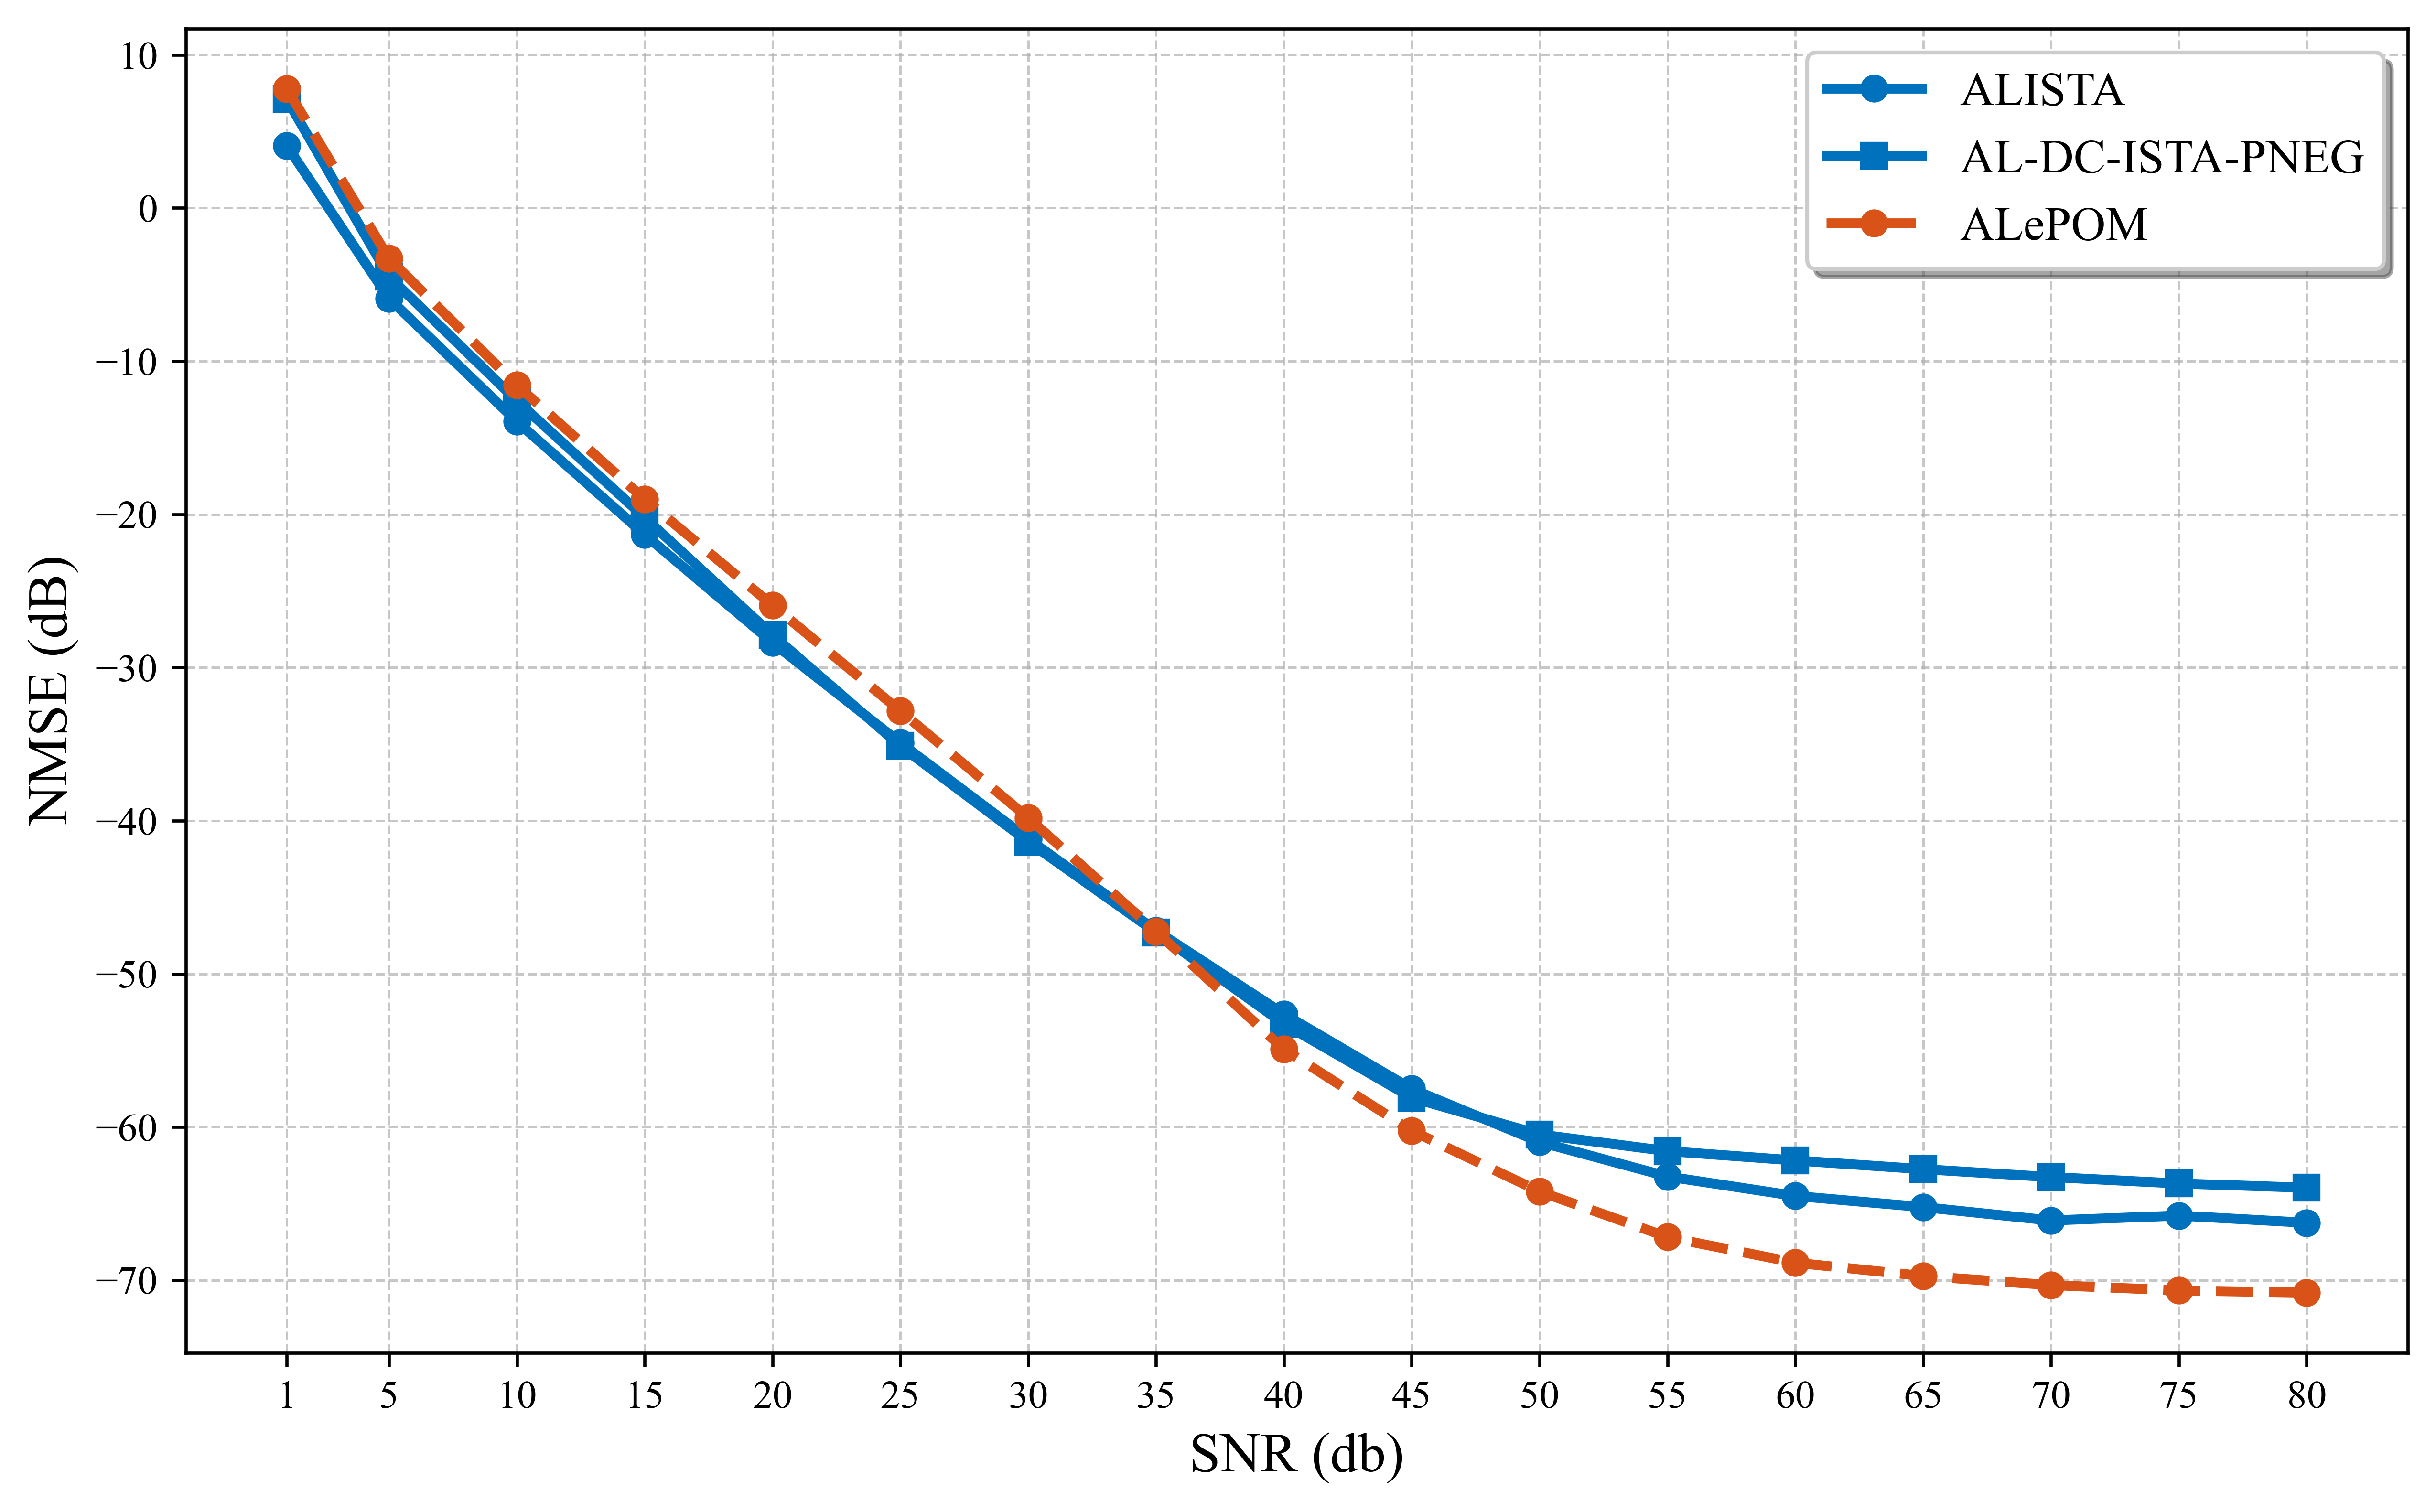

In [35]:
# Set global font
plt.rcParams["font.family"] = "Times New Roman"

# Increase figure size for better visibility
plt.figure(figsize=(10, 6), dpi=600)

models = [
    'ALISTA',
    'AL-DC-ISTA-PNEG',
    'ALePOM',
]

linestyles = [
    "-",    # Solid
    "-",   # Dashed
    "--",    # Solid
    "--",   # Dashed
    ":",
    ":"]

markers = ["o", "s", "o", "s", "o", "s"]
colors = [
    [0, 0.4470, 0.7410],   
    [0, 0.4470, 0.7410],  
    [0.8500, 0.3250, 0.0980],  
    [0.8500, 0.3250, 0.0980],  
    [0.9290, 0.6940, 0.1250],  
    [0.9290, 0.6940, 0.1250]   
]


# Plot each model
for i, model_ in enumerate(models):
    plt.plot(SNRs, 
             [noisy_scenarios[SNR_][model_] / 10 for SNR_ in SNRs], 
             label=models[i], 
             color=colors[i], 
             marker=markers[i], 
             linestyle=linestyles[i],
             markersize=6, 
             linewidth=2.5)
plt.xticks(SNRs)

# Axis labels
plt.ylabel('NMSE (dB)', fontsize=14)
plt.xlabel('SNR (db)', fontsize=14)

# Beautify the grid
plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.7)

# Adjust legend placement
plt.legend(fontsize=12, fancybox=True, shadow=True, frameon=True, loc='upper right')

# Show the plot
plt.show()

# Probability of correct support selection 

In [4]:
n_ = 500
m_ = 250
p_ = 0.2

torch.random.manual_seed(42)
A_ = torch.normal(0, torch.sqrt(torch.tensor(1/m_)), size = (m_, n_))
A_ /= torch.linalg.norm(A_, dim = 0)

'''
train_set = SyntheticSignals(
        A = A_,
        n = n_,        
        m = m_,
        p = p_,
        SNR = None,
        size = 50000,
        batch_size = 64
        ).set_loader()

val_set = SyntheticSignals(
        A = A_,
        n = n_,        
        m = m_,
        p = p_,
        SNR = None,
        size = 50000,
        batch_size = 1000
        ).set_loader()
'''

generator = SyntheticSignalsOnline(
        A = A_,
        n = n_,        
        m = m_,
        p = p_,
        SNR = None
        )

In [ ]:
model_1 = ALISTA(torch.clone(A_), 0.1, T = 32, SS = False)
layerwise_train(model_1, 'C', 'ALISTA', generator, lr = 5e-4, ft_lr = 5e-4, verbose=True)

In [ ]:
model_2 = ALDC_ISTA(torch.clone(A_), 'PNEG', 0.1, T = 32, W = torch.clone(model_1.W).to('cuda:0'), SS = False)
layerwise_train(model_2, 'DC', 'AL-DC-ISTA', generator, 'PNEG', lr = 5e-4, ft_lr = 5e-4, verbose=True)

In [ ]:
model_3 = LISTA_CPSS(torch.clone(A_), 0.1, T = 32, SS = False)
layerwise_train(model_3, 'C', 'LISTA-CPSS', generator, lr = 5e-4, ft_lr = 5e-4, verbose=True)

In [ ]:
model_4 = L_DC_ISTA_CPSS(torch.clone(A_), 'PNEG', 0.1, T = 32, SS = False)
layerwise_train(model_4, 'DC', 'L-DC-ISTA-CPSS', generator, 'PNEG', lr = 5e-4, ft_lr = 5e-4, verbose=True)

In [ ]:
model_5 = ALePOM(torch.clone(A_), 0.1, T = 32, W = torch.clone(model_1.W).to('cuda:0'))
layerwise_train(model_5, 'POM', 'ALePOM', generator, lr = 5e-4, ft_lr = 5e-4, verbose=True)

In [ ]:
model_6 = LePOM_CP(torch.clone(A_), 0.1, T = 32)
layerwise_train(model_6, 'POM', 'LePOM', generator, lr = 5e-4, ft_lr = 5e-4, verbose=True)

In [ ]:
torch.save(model_1.state_dict(), "model_1a_SUPPORT_weights.pth")
torch.save(model_2.state_dict(), "model_2a_SUPPORT_weights.pth")
torch.save(model_3.state_dict(), "model_3a_SUPPORT_weights.pth")
torch.save(model_4.state_dict(), "model_4a_SUPPORT_weights.pth")
torch.save(model_5.state_dict(), "model_5a_SUPPORT_weights.pth")
torch.save(model_6.state_dict(), "model_6a_SUPPORT_weights.pth")

In [5]:
model_1 = ALISTA(torch.clone(A_), 0.1, T = 32, SS = False)
model_2 = ALDC_ISTA(torch.clone(A_), 'PNEG', 0.1, T = 32, W = torch.clone(model_1.W).to('cuda:0'), SS = False)
model_3 = LISTA_CPSS(torch.clone(A_), 0.1, T = 32, SS = False)
model_4 = L_DC_ISTA_CPSS(torch.clone(A_), 'PNEG', 0.1, T = 32, SS = False)
model_2 = ALDC_ISTA(torch.clone(A_), 'EXP', 0.4, T = 32, W = torch.clone(model_1.W).to('cuda:0'), SS = False)
model_5 = ALePOM(torch.clone(A_), 0.1, T = 32, W = torch.clone(model_1.W).to('cuda:0'))
model_6 = LePOM_CP(torch.clone(A_), 0.1, T = 32)

Linear layer initialized minimizing coherence!


In [13]:
torch.load('model_2a_SUPPORT_weights.pth')

OrderedDict([('lambd.0', tensor([[0.5595]], device='cuda:0')),
             ('lambd.1', tensor([[2.2333]], device='cuda:0')),
             ('lambd.2', tensor([[0.3521]], device='cuda:0')),
             ('lambd.3', tensor([[1.8111]], device='cuda:0')),
             ('lambd.4', tensor([[0.2036]], device='cuda:0')),
             ('lambd.5', tensor([[1.1955]], device='cuda:0')),
             ('lambd.6', tensor([[0.1775]], device='cuda:0')),
             ('lambd.7', tensor([[0.1714]], device='cuda:0')),
             ('lambd.8', tensor([[0.0169]], device='cuda:0')),
             ('lambd.9', tensor([[0.5484]], device='cuda:0')),
             ('lambd.10', tensor([[0.0904]], device='cuda:0')),
             ('lambd.11', tensor([[0.0889]], device='cuda:0')),
             ('lambd.12', tensor([[0.0845]], device='cuda:0')),
             ('lambd.13', tensor([[0.0344]], device='cuda:0')),
             ('lambd.14', tensor([[0.0243]], device='cuda:0')),
             ('lambd.15', tensor([[0.0393]], devic

In [15]:
model_1.load_state_dict(torch.load('model_1a_SUPPORT_weights.pth'))
#model_2.load_state_dict(torch.load('model_2a_SUPPORT_weights.pth'))
model_3.load_state_dict(torch.load('model_3a_SUPPORT_weights.pth'))
model_4.load_state_dict(torch.load('model_4a_SUPPORT_weights.pth'))
model_5.load_state_dict(torch.load('model_5a_SUPPORT_weights.pth'))
model_6.load_state_dict(torch.load('model_6a_SUPPORT_weights.pth'))

<All keys matched successfully>

In [10]:
model_2.load_state_dict(torch.load('model_2a_SUPPORT_weights.pth'))


RuntimeError: Error(s) in loading state_dict for ALDC_ISTA:
	Unexpected key(s) in state_dict: "P.0", "P.1", "P.2", "P.3", "P.4", "P.5", "P.6", "P.7", "P.8", "P.9", "P.10", "P.11", "P.12", "P.13", "P.14", "P.15", "P.16", "P.17", "P.18", "P.19", "P.20", "P.21", "P.22", "P.23", "P.24", "P.25", "P.26", "P.27", "P.28", "P.29", "P.30", "P.31", "P.32". 

In [26]:
def compute_support(model, test_loader, verbose=False):
    total_successful_recoveries = 0
    total_samples = 0

    for _, (Y, S) in enumerate(test_loader):
        Y, S = Y.to(model.device), S.to(model.device)
        X = model.forward(y=Y, its=None).detach()  # Detach to avoid unnecessary gradients

        # Create binary support masks for X and S
        X_thresholded = (torch.abs(X) > 0).float()  # Binary mask (0 or 1)
        S_support = (S != 0).float()

        # Check if the recovered support exactly matches the true support
        successful_recovery = torch.all(X_thresholded == S_support, dim=1).float()
        total_successful_recoveries += successful_recovery.sum().item()
        total_samples += S.shape[0]

    # Compute probability of successful recovery
    successful_recovery_probability = total_successful_recoveries / total_samples if total_samples > 0 else 0.0

    return successful_recovery_probability

In [30]:
ps = np.arange(0.01,0.2,0.02)

In [31]:
ps

array([0.01, 0.03, 0.05, 0.07, 0.09, 0.11, 0.13, 0.15, 0.17, 0.19])

In [32]:
precisions_1 = {p:0 for p in ps}
precisions_2 = {p:0 for p in ps}
precisions_3 = {p:0 for p in ps}
precisions_4 = {p:0 for p in ps}
precisions_5 = {p:0 for p in ps}
precisions_6 = {p:0 for p in ps}


for _ in tqdm(range(15)):
  for p in ps:
    test_set = SyntheticSignals(
      A = A_,
      n = n_,
      m = m_,
      p = p,
      SNR = None,
      size = 1000,
      discretized = True
      ).set_loader()

    precisions_1[p] += compute_support(model_1, test_set)
    precisions_2[p] += compute_support(model_2, test_set)
    precisions_3[p] += compute_support(model_3, test_set)
    precisions_4[p] += compute_support(model_4, test_set)
    precisions_5[p] += compute_support(model_5, test_set)
    precisions_6[p] += compute_support(model_6, test_set)

100%|██████████| 15/15 [01:10<00:00,  4.67s/it]


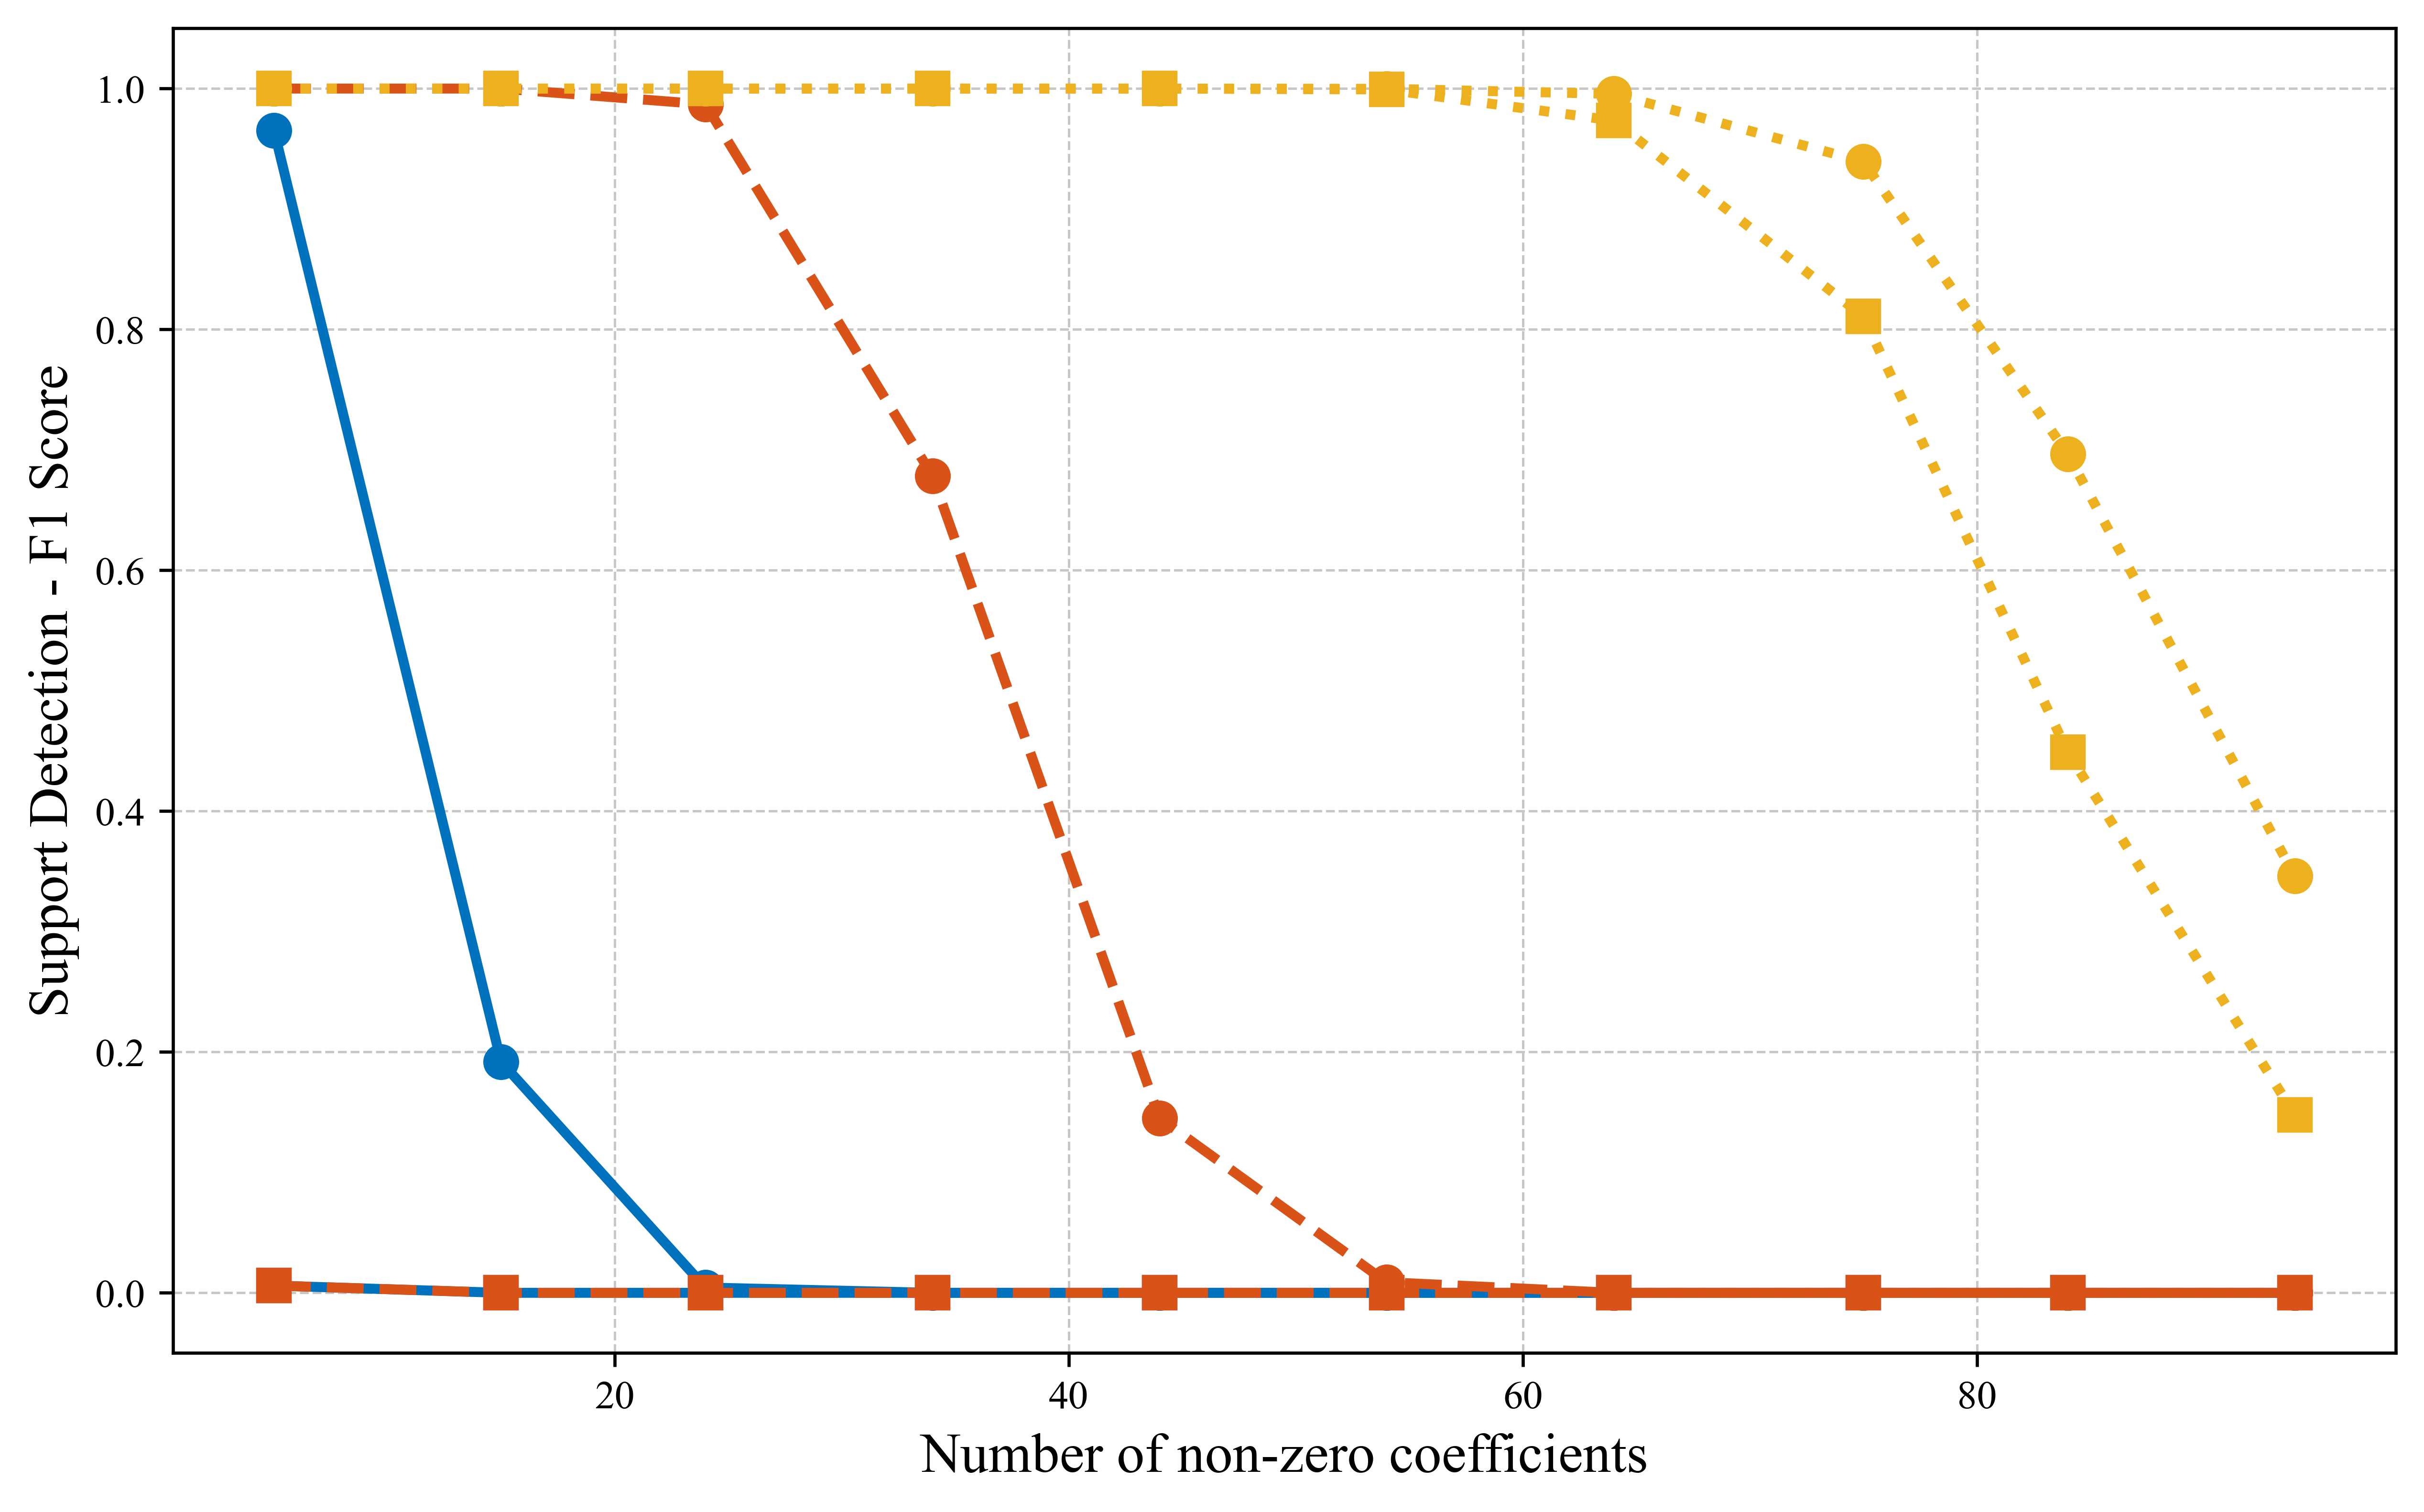

In [34]:
# Set global font
plt.rcParams["font.family"] = "Times New Roman"

# Increase figure size for better visibility
plt.figure(figsize=(10, 6), dpi=600)

models = [
    'ALISTA',
    'LISTA-CPSS',
    'AL-DC-ISTA (PNEG)',
    'L-DC-ISTA-CPSS (PNEG)',
    'ALePOM (MCP)',
    'LePOM (MCP)'
]

linestyles = [
    "-",    # Solid
    "-",   # Dashed
    "--",    # Solid
    "--",   # Dashed
    ":",
    ":"]

markers = ["o", "s", "o", "s", "o", "s"]
colors = [
    [0, 0.4470, 0.7410],   
    [0, 0.4470, 0.7410],  
    [0.8500, 0.3250, 0.0980],  
    [0.8500, 0.3250, 0.0980],  
    [0.9290, 0.6940, 0.1250],  
    [0.9290, 0.6940, 0.1250]   
]


precisions = {
    'ALISTA':[precisions_1[p] / 15 for p in ps],
    'LISTA-CPSS':[precisions_3[p] / 15 for p in ps],
    'AL-DC-ISTA (PNEG)':[precisions_2[p] / 15 for p in ps],
    'L-DC-ISTA-CPSS (PNEG)':[precisions_4[p] / 15 for p in ps],
    'ALePOM (MCP)':[precisions_5[p] / 15 for p in ps],
    'LePOM (MCP)':[precisions_6[p] / 15 for p in ps]
}

# Plot each model
for i, model in enumerate(models):
    plt.plot(
        [int(p * 500) for p in ps][0:10], precisions[model][0:10],
        label=model, color=colors[i], marker=markers[i], linestyle=linestyles[i],
        markersize=8, linewidth=2.5  # Reduced marker size and linewidth for clarity
    )

# Axis labels
plt.xlabel('Number of non-zero coefficients', fontsize=14)
plt.ylabel('Support Detection - F1 Score', fontsize=14)

# Beautify the grid
plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.7)

# Adjust legend placement
#plt.legend(fontsize=12, fancybox=True, shadow=True, frameon=True, loc='upper right')

# Show the plot
plt.show()

In [58]:
SNRs = [1] + list(range(5,81,5))
n_ = 500
m_ = 250
p_ = 0.2

noisy_scenarios = {SNR: {
    'ALISTA':0,
    'LISTA-CPSS':0,
    'AL-DC-ISTA-PNEG':0,
    'L-DC-ISTA-CPSS-PNEG':0,
    'LePOM':0,
    'ALePOM':0
} for SNR in SNRs}

In [59]:
for SNR_ in tqdm(SNRs):
    for _ in range(10):
        test_set = SyntheticSignals(
            A = A_,
            n = n_,        
            m = m_,
            p = p_,
            SNR = 10**(SNR_/10),
            size = 1000
            ).set_loader()

        noisy_scenarios[SNR_]['ALISTA'] += model_1.compute_nmse_inference(test_set)[-1].cpu()
        noisy_scenarios[SNR_]['LISTA-CPSS'] += model_3.compute_nmse_inference(test_set)[-1].cpu()

        noisy_scenarios[SNR_]['AL-DC-ISTA-PNEG'] += model_2.compute_nmse_inference(test_set)[-1].cpu()
        noisy_scenarios[SNR_]['L-DC-ISTA-CPSS-PNEG'] += model_4.compute_nmse_inference(test_set)[-1].cpu()

        noisy_scenarios[SNR_]['LePOM'] += model_5.compute_nmse_inference(test_set)[-1].cpu()
        noisy_scenarios[SNR_]['ALePOM'] += model_6.compute_nmse_inference(test_set)[-1].cpu()

100%|██████████| 17/17 [01:51<00:00,  6.57s/it]


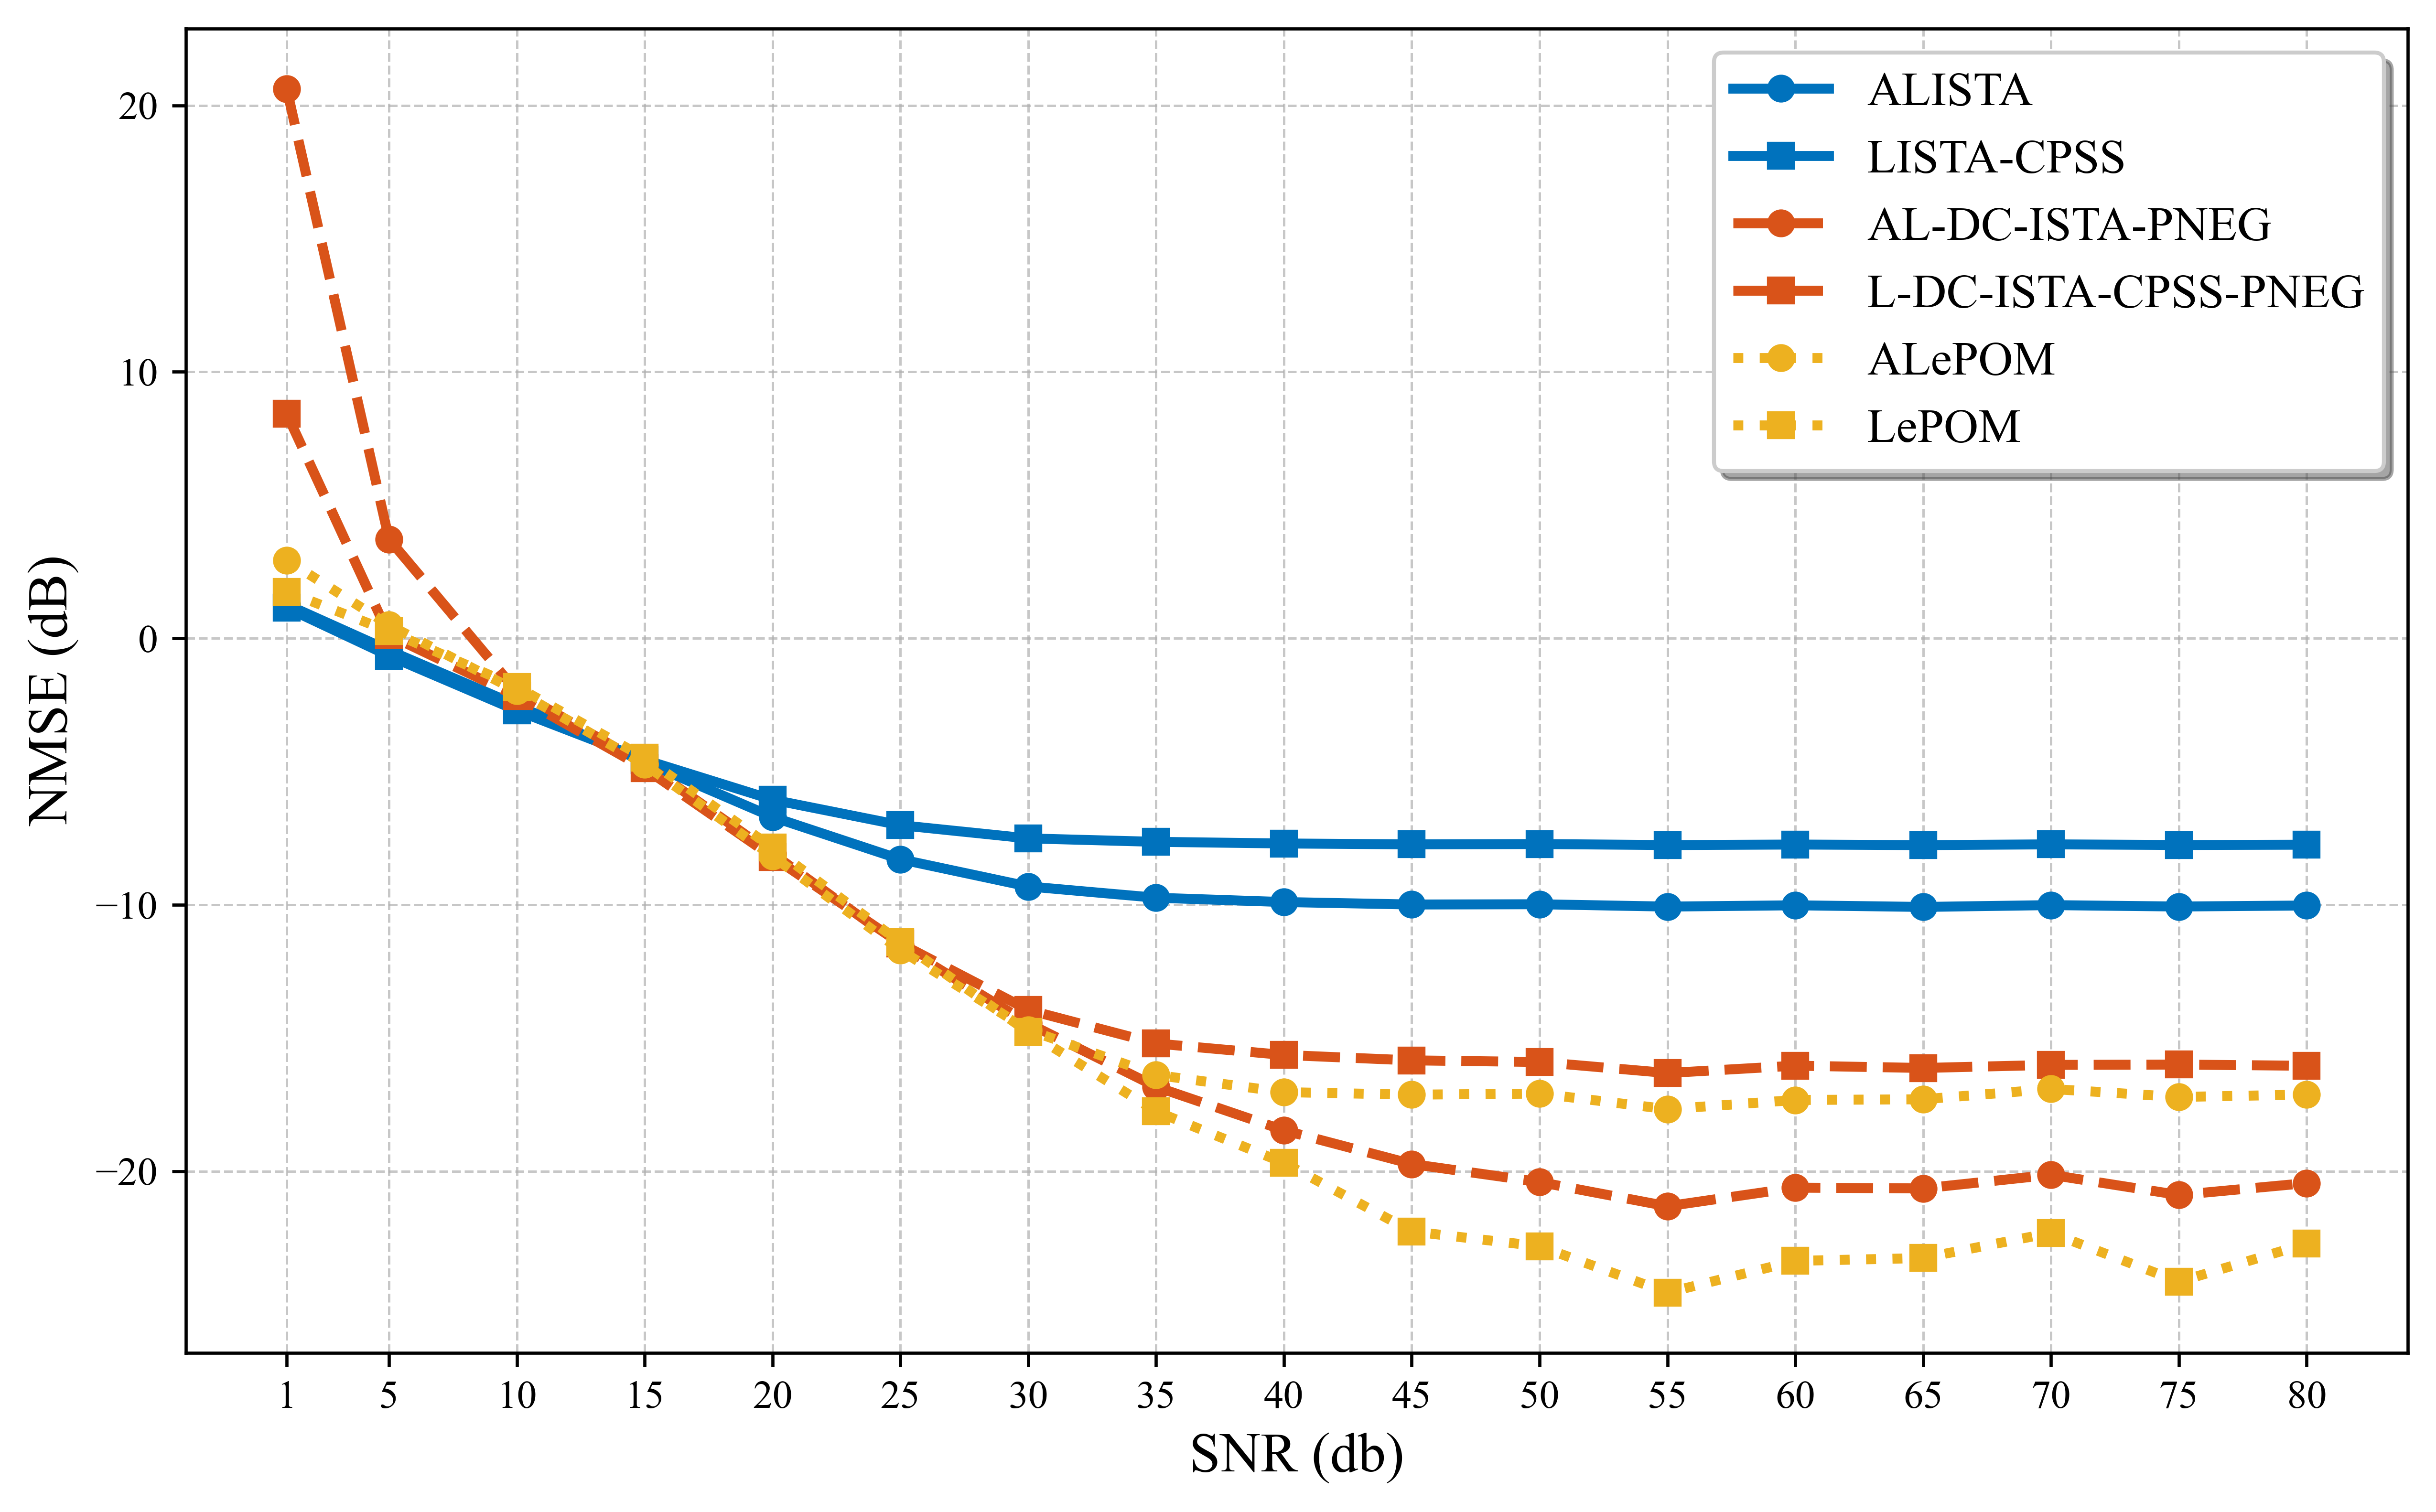

In [61]:
# Set global font
plt.rcParams["font.family"] = "Times New Roman"

# Increase figure size for better visibility
plt.figure(figsize=(10, 6), dpi=600)

models = [
    'ALISTA',
    'LISTA-CPSS',
    'AL-DC-ISTA-PNEG',
    'L-DC-ISTA-CPSS-PNEG',
    'ALePOM',
    'LePOM'
]

linestyles = [
    "-",    # Solid
    "-",   # Dashed
    "--",    # Solid
    "--",   # Dashed
    ":",
    ":"]

markers = ["o", "s", "o", "s", "o", "s"]
colors = [
    [0, 0.4470, 0.7410],   
    [0, 0.4470, 0.7410],  
    [0.8500, 0.3250, 0.0980],  
    [0.8500, 0.3250, 0.0980],  
    [0.9290, 0.6940, 0.1250],  
    [0.9290, 0.6940, 0.1250]   
]


# Plot each model
for i, model_ in enumerate(models):
    plt.plot(SNRs, [noisy_scenarios[SNR_][model_] / 17 for SNR_ in SNRs], label=models[i], color=colors[i], marker=markers[i], linestyle=linestyles[i],
        markersize=6, linewidth=2.5)
plt.xticks(SNRs)

# Axis labels
plt.ylabel('NMSE (dB)', fontsize=14)
plt.xlabel('SNR (db)', fontsize=14)

# Beautify the grid
plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.7)

# Adjust legend placement
plt.legend(fontsize=12, fancybox=True, shadow=True, frameon=True, loc='upper right')

# Show the plot
plt.show()